<a href="https://colab.research.google.com/github/zaid9281/NLP-Anoja_samatrix/blob/main/assingment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Mohammad Zaid

Class: B.Tech CSE AI-ML

Sec-A

Roll no.: 2401730232

Anoja Samatrix

# NLP Assignment: Word2Vec + LSTM and a Fine-Tuned DistilBERT



**Questions**
1. Implement a complete **Word2Vec + LSTM** text-classification pipeline.
2. Fine-tune a pretrained Transformer, **DistilBERT**, for text classification.

Both models are trained on the same task: deciding whether an **IMDb movie review** is negative (`0`) or positive (`1`). To keep training quick, only a random subset of the dataset is used (2,000 reviews to train, 400 to validate, 500 to test).


In [ ]:
# run once: installs the libraries used by both questions
%pip install -q gensim transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 29.9 MB/s eta 0:00:00


In [ ]:
import copy
import os
import random
import re

In [ ]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

In [ ]:
import matplotlib.pyplot as plt
from datasets import load_dataset
from gensim.models import Word2Vec
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, f1_score)

In [ ]:
# fixed seeds so reruns give similar results
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training device:", DEVICE)

Training device: cpu


---
## Question 1: Word2Vec + LSTM classification pipeline

The idea: Word2Vec first learns a vector for every word from the review text itself. Those vectors are then used as the input layer of an LSTM, which reads each review word by word and decides whether it is positive or negative.

### Step 1: Load a small IMDb dataset

One detail matters here. The IMDb files are stored **sorted by label**, with all the negative reviews first. Slicing the first 1,000 rows would therefore give a dataset with only one class. To avoid that, the data is shuffled *before* the subsets are cut out.

In [ ]:
imdb = load_dataset("stanfordnlp/imdb")

train_full = imdb["train"].shuffle(seed=SEED)
test_full  = imdb["test"].shuffle(seed=SEED)

train_data = train_full.select(range(0, 2000))
valid_data = train_full.select(range(2000, 2400))
test_data  = test_full.select(range(0, 500))

train_texts, valid_texts, test_texts = train_data["text"], valid_data["text"], test_data["text"]
train_labels = np.array(train_data["label"])
valid_labels = np.array(valid_data["label"])
test_labels  = np.array(test_data["label"])

print("Training examples  :", len(train_texts))
print("Validation examples:", len(valid_texts))
print("Testing examples   :", len(test_texts))

print("\nLabel counts in the training data (0 = negative, 1 = positive):")
print(pd.Series(train_labels).value_counts().sort_index().to_string())

first_pos = int(np.where(train_labels == 1)[0][0])
print("\nOne positive review (first 400 characters):")
print(train_texts[first_pos][:400])

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Training examples  : 2000
Validation examples: 400
Testing examples   : 500

Label counts in the training data (0 = negative, 1 = positive):
0    1000
1    1000

One positive review (first 400 characters):
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compa


Step 2: Clean the text

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<br\s*/?>", " ", text)       # IMDb reviews contain <br /> tags
    text = re.sub(r"[^a-z' ]+", " ", text)       # keep letters and apostrophes only
    words = [w.strip("'") for w in text.split()]
    return [w for w in words if w]

train_sentences = [clean_text(t) for t in train_texts]
valid_sentences = [clean_text(t) for t in valid_texts]
test_sentences  = [clean_text(t) for t in test_texts]

print("Original :", train_texts[0][:250])
print("\nCleaned  :", train_sentences[0][:30])
print("\nAverage review length:", round(np.mean([len(s) for s in train_sentences])), "words")

Original : There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier 

Cleaned  : ['there', 'is', 'no', 'relation', 'at', 'all', 'between', 'fortier', 'and', 'profiler', 'but', 'the', 'fact', 'that', 'both', 'are', 'police', 'series', 'about', 'violent', 'crimes', 'profiler', 'looks', 'crispy', 'fortier', 'looks', 'classic', 'profiler', 'plots', 'are']

Average review length: 227 words


Step 3: Train Word2Vec
Skip-gram Word2Vec learns to predict the words around a given word, and in doing so places words that are used in similar ways close together. It is trained on the training reviews only, so nothing from the validation or test reviews leaks in.

In [ ]:
EMBEDDING_SIZE = 100

word2vec_model = Word2Vec(
    sentences=train_sentences,
    vector_size=EMBEDDING_SIZE,   # numbers per word
    window=5,                     # words of context on each side
    min_count=2,                  # ignore words seen fewer than 2 times
    sg=1,                         # 1 = skip-gram
    epochs=15,
    workers=4,
    seed=SEED,
)

print("Word2Vec vocabulary size:", len(word2vec_model.wv.index_to_key))
print("Vector shape of one word:", word2vec_model.wv["movie"].shape)

for query in ("movie", "great", "boring"):
    print(f'\nWords closest to "{query}":')
    for word, score in word2vec_model.wv.most_similar(query, topn=5):
        print(f"  {word:15s} {score:.3f}")

Word2Vec vocabulary size: 14114
Vector shape of one word: (100,)

Words closest to "movie":
  film            0.791
  tripe           0.738
  recipe          0.724
  thrill          0.723
  avoiding        0.718

Words closest to "great":
  wonderful       0.616
  fine            0.563
  tremendous      0.562
  consist         0.550
  solid           0.548

Words closest to "boring":
  ridiculously    0.688
  gross           0.671
  cheese          0.670
  gory            0.661
  celina          0.652


### Step 4: Word IDs and the embedding matrix

A neural network works with numbers, so every word gets an integer ID. ID `0` is reserved for padding and ID `1` for words that Word2Vec did not learn. The embedding matrix holds one Word2Vec vector per ID, and it will become the input layer of the LSTM.

In [ ]:
word_to_id = {"<PAD>": 0, "<UNK>": 1}
for word in word2vec_model.wv.index_to_key:
    word_to_id[word] = len(word_to_id)

vocab_size = len(word_to_id)

embedding_matrix = np.zeros((vocab_size, EMBEDDING_SIZE), dtype=np.float32)   # row 0 (padding) stays zero
embedding_matrix[1] = np.random.normal(0, 0.05, EMBEDDING_SIZE)               # small random vector for <UNK>
for word, idx in word_to_id.items():
    if word in word2vec_model.wv:
        embedding_matrix[idx] = word2vec_model.wv[word]

print("Vocabulary size used by the LSTM:", vocab_size)
print("Embedding matrix shape          :", embedding_matrix.shape)

Vocabulary size used by the LSTM: 14116
Embedding matrix shape          : (14116, 100)


Step 5: Fixed-length sequences
Every review must be the same length to be batched. Long reviews are cut at 200 words and short ones are padded with zeros. The true length of each review is also stored, so the LSTM can later ignore the padding.

In [ ]:
MAX_WORDS = 200

def make_sequence(words):
    ids = [word_to_id.get(w, 1) for w in words[:MAX_WORDS]]
    length = max(len(ids), 1)                       # never zero, the LSTM needs at least one step
    ids = ids + [0] * (MAX_WORDS - len(ids))
    return ids, length

def build_sequences(sentences):
    pairs = [make_sequence(s) for s in sentences]
    return [p[0] for p in pairs], [p[1] for p in pairs]

train_seq, train_len = build_sequences(train_sentences)
valid_seq, valid_len = build_sequences(valid_sentences)
test_seq,  test_len  = build_sequences(test_sentences)

print("Sequences in training set:", len(train_seq))
print("Length of every sequence :", len(train_seq[0]))
print("First 15 IDs of review 1 :", train_seq[0][:15])
print("Real length of review 1  :", train_len[0], "words")

Sequences in training set: 2000
Length of every sequence : 200
First 15 IDs of review 1 : [47, 7, 59, 10118, 30, 29, 188, 8051, 3, 10117, 18, 2, 185, 12, 201]
Real length of review 1  : 124 words



Step 6: PyTorch datasets and data loaders

In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.lengths   = torch.tensor(lengths, dtype=torch.long)
        self.labels    = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.sequences[i], self.lengths[i], self.labels[i]

BATCH_SIZE = 32
train_loader = DataLoader(ReviewDataset(train_seq, train_len, train_labels), batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(ReviewDataset(valid_seq, valid_len, valid_labels), batch_size=BATCH_SIZE)
test_loader  = DataLoader(ReviewDataset(test_seq,  test_len,  test_labels),  batch_size=BATCH_SIZE)

seqs, lens, labs = next(iter(train_loader))
print("Batch of sequences:", tuple(seqs.shape))
print("Batch of lengths  :", tuple(lens.shape))
print("Batch of labels   :", tuple(labs.shape))

Batch of sequences: (32, 200)
Batch of lengths  : (32,)
Batch of labels   : (32,)


Step 7: The LSTM model
The embedding layer starts from the Word2Vec vectors (and is allowed to adjust during training). A bidirectional LSTM then reads each review forwards and backwards, and its two final states are joined and passed through a single output unit. Packing the sequences means the LSTM stops at each review's real last word instead of running through the padding zeros.

In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, embedding_matrix, hidden_size=64, dropout=0.4):
        super().__init__()
        weights = torch.tensor(embedding_matrix, dtype=torch.float32)
        self.embedding = nn.Embedding.from_pretrained(weights, freeze=False, padding_idx=0)
        self.lstm = nn.LSTM(weights.shape[1], hidden_size, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.output_layer = nn.Linear(hidden_size * 2, 1)

    def forward(self, sequence, lengths):
        embedded = self.embedding(sequence)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)

        # last forward state + last backward state
        final_state = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.output_layer(self.dropout(final_state)).squeeze(1)

lstm_model = SentimentLSTM(embedding_matrix).to(DEVICE)
print(lstm_model)
print("\nTrainable parameters:", sum(p.numel() for p in lstm_model.parameters() if p.requires_grad))

SentimentLSTM(
  (embedding): Embedding(14116, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)

Trainable parameters: 1496721


Step 8: Train the model
The model is trained for 8 epochs. After every epoch it is scored on the validation reviews, and the version with the best validation accuracy is the one kept at the end.

In [ ]:
def evaluate_accuracy(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for seqs, lens, labels in loader:
            seqs, labels = seqs.to(DEVICE), labels.to(DEVICE)
            preds = (torch.sigmoid(model(seqs, lens)) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
EPOCHS = 8

training_losses, validation_accuracies = [], []
best_accuracy, best_state = 0.0, None

for epoch in range(1, EPOCHS + 1):
    lstm_model.train()
    running_loss = 0.0

    for seqs, lens, labels in train_loader:
        seqs, labels = seqs.to(DEVICE), labels.to(DEVICE)

        loss = loss_function(lstm_model(seqs, lens), labels)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)    # keeps LSTM training stable
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    val_acc = evaluate_accuracy(lstm_model, valid_loader)
    training_losses.append(avg_loss)
    validation_accuracies.append(val_acc)

    if val_acc > best_accuracy:
        best_accuracy, best_state = val_acc, copy.deepcopy(lstm_model.state_dict())

    print(f"Epoch {epoch}/{EPOCHS} | loss {avg_loss:.4f} | validation accuracy {val_acc:.4f}")

lstm_model.load_state_dict(best_state)
print(f"\nKept the best model (validation accuracy {best_accuracy:.4f})")

Epoch 1/8 | loss 0.6906 | validation accuracy 0.5000
Epoch 2/8 | loss 0.6359 | validation accuracy 0.6150
Epoch 3/8 | loss 0.4589 | validation accuracy 0.7325
Epoch 4/8 | loss 0.3154 | validation accuracy 0.7575
Epoch 5/8 | loss 0.2403 | validation accuracy 0.7475
Epoch 6/8 | loss 0.1538 | validation accuracy 0.7500
Epoch 7/8 | loss 0.0827 | validation accuracy 0.8000
Epoch 8/8 | loss 0.0426 | validation accuracy 0.7875

Kept the best model (validation accuracy 0.8000)


Step 9: Training graph

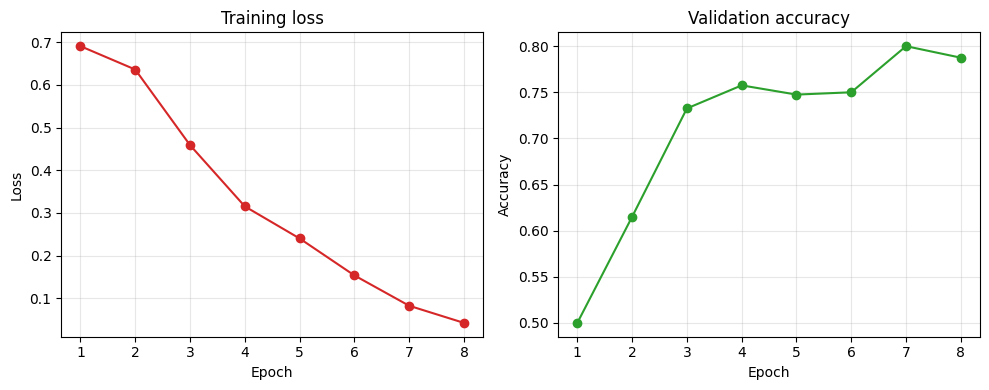

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
epochs_axis = range(1, EPOCHS + 1)

ax[0].plot(epochs_axis, training_losses, marker="o", color="tab:red")
ax[0].set_title("Training loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(alpha=0.3)

ax[1].plot(epochs_axis, validation_accuracies, marker="o", color="tab:green")
ax[1].set_title("Validation accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Step 10: Test the Word2Vec + LSTM model

In [ ]:
def lstm_predict(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for seqs, lens, _ in loader:
            probs.extend(torch.sigmoid(model(seqs.to(DEVICE), lens)).cpu().numpy())
    probs = np.array(probs)
    return (probs >= 0.5).astype(int), probs

lstm_predictions, lstm_probs = lstm_predict(lstm_model, test_loader)

lstm_accuracy = accuracy_score(test_labels, lstm_predictions)
lstm_f1 = f1_score(test_labels, lstm_predictions)

print("WORD2VEC + LSTM: TEST RESULTS")
print("Accuracy:", round(lstm_accuracy, 4))
print("F1-score:", round(lstm_f1, 4))
print("\nClassification report:")
print(classification_report(test_labels, lstm_predictions, target_names=["Negative", "Positive"], digits=4))

WORD2VEC + LSTM: TEST RESULTS
Accuracy: 0.734
F1-score: 0.7356

Classification report:
              precision    recall  f1-score   support

    Negative     0.7490    0.7165    0.7324       254
    Positive     0.7198    0.7520    0.7356       246

    accuracy                         0.7340       500
   macro avg     0.7344    0.7343    0.7340       500
weighted avg     0.7346    0.7340    0.7340       500




Step 11: Confusion matrix

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    test_labels, lstm_predictions,
    display_labels=["Negative", "Positive"], cmap="Blues", colorbar=False)
plt.title("Word2Vec + LSTM: confusion matrix")
plt.show()

Step 12: Predict new reviews

In [ ]:
def predict_with_lstm(review):
    ids, length = make_sequence(clean_text(review))
    seq = torch.tensor([ids], dtype=torch.long).to(DEVICE)
    lstm_model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(lstm_model(seq, torch.tensor([length]))).item()
    return ("Positive" if prob >= 0.5 else "Negative"), prob

new_reviews = [
    "This movie was excellent. The acting was great and the story was very interesting.",
    "A dull, predictable film. I was bored from the first scene and the ending was terrible.",
    "I expected a great film, but it was not good at all.",
]

print("WORD2VEC + LSTM")
for review in new_reviews:
    label, prob = predict_with_lstm(review)
    print(f"{label:8s} (positive probability {prob:.3f})  {review}")

In [ ]:
os.makedirs("saved_models", exist_ok=True)
torch.save(lstm_model.state_dict(), "saved_models/word2vec_lstm_model.pt")
word2vec_model.save("saved_models/word2vec_model.bin")
print("Saved: saved_models/word2vec_lstm_model.pt and saved_models/word2vec_model.bin")

Question 2: Fine-tune DistilBERT for text classification
DistilBERT is a smaller, faster version of BERT that keeps most of its accuracy. It has already been pretrained on a very large amount of English text, so it arrives knowing a lot about language. Fine-tuning only has to teach it this particular task: one extra classification layer is added on top, and the whole network is trained for a couple of epochs on the labelled reviews.

The same training, validation and test reviews from Question 1 are used, so the two models can be compared fairly.

Step 1: Load the tokenizer and model

In [ ]:
import inspect
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                          DataCollatorWithPadding, Trainer, TrainingArguments)

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256

bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)

print("Model                   :", MODEL_NAME)
print("Tokenizer vocabulary    :", len(bert_tokenizer))
print("Maximum tokens per input:", MAX_LENGTH)
print("Parameters              :", f"{sum(p.numel() for p in bert_model.parameters()):,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model                   : distilbert-base-uncased
Tokenizer vocabulary    : 30522
Maximum tokens per input: 256
Parameters              : 66,955,010



Step 2: Tokenize the same dataset
The tokenizer splits text into word pieces and gives back input_ids (the IDs of those pieces) and an attention_mask (which marks real tokens versus padding). Padding is added per batch rather than up to the maximum length, which saves time.

In [ ]:
def tokenize_reviews(batch):
    return bert_tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

bert_train = train_data.map(tokenize_reviews, batched=True)
bert_valid = valid_data.map(tokenize_reviews, batched=True)
bert_test  = test_data.map(tokenize_reviews, batched=True)

# the Trainer expects the label column to be called "labels" and only needs the numeric columns
bert_train = bert_train.rename_column("label", "labels").remove_columns(["text"])
bert_valid = bert_valid.rename_column("label", "labels").remove_columns(["text"])
bert_test  = bert_test.rename_column("label", "labels").remove_columns(["text"])

print(bert_train)
print("\nFirst 20 input IDs of review 1:", bert_train[0]["input_ids"][:20])
print("Decoded back:", bert_tokenizer.decode(bert_train[0]["input_ids"][:20]))

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})

First 20 input IDs of review 1: [101, 2045, 2003, 2053, 7189, 2012, 2035, 2090, 3481, 3771, 1998, 6337, 2099, 2021, 1996, 2755, 2008, 2119, 2024, 2610]
Decoded back: [CLS] there is no relation at all between fortier and profiler but the fact that both are police


### Step 3: Evaluation metrics

Step 4: Fine-tune with the Trainer
The argument that turns on per-epoch evaluation was renamed in recent versions of transformers (evaluation_strategy became eval_strategy), so the cell checks which name the installed version uses.

In [ ]:
eval_arg = "eval_strategy" if "eval_strategy" in inspect.signature(TrainingArguments.__init__).parameters \
           else "evaluation_strategy"

training_args = TrainingArguments(
    output_dir="distilbert_output",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=25,
    save_strategy="no",
    report_to="none",
    fp16=torch.cuda.is_available(),      # faster on a GPU
    seed=SEED,
    **{eval_arg: "epoch"},
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=bert_train,
    eval_dataset=bert_valid,
    data_collator=DataCollatorWithPadding(bert_tokenizer),
    compute_metrics=compute_metrics,
)

trainer.train()

NameError: name 'compute_metrics' is not defined

Step 5: Validation results

In [ ]:
validation_results = trainer.evaluate()

print("DISTILBERT: VALIDATION RESULTS")
for name, value in validation_results.items():
    if isinstance(value, float):
        print(f"{name}: {value:.4f}")

In [ ]:
test_output = trainer.predict(bert_test)
bert_predictions = np.argmax(test_output.predictions, axis=1)

bert_accuracy = accuracy_score(test_labels, bert_predictions)
bert_f1 = f1_score(test_labels, bert_predictions)

print("DISTILBERT: TEST RESULTS")
print("Accuracy:", round(bert_accuracy, 4))
print("F1-score:", round(bert_f1, 4))
print("\nClassification report:")
print(classification_report(test_labels, bert_predictions, target_names=["Negative", "Positive"], digits=4))

DISTILBERT: TEST RESULTS
Accuracy: 0.876
F1-score: 0.8735

Classification report:
              precision    recall  f1-score   support

    Negative     0.8750    0.8819    0.8784       254
    Positive     0.8770    0.8699    0.8735       246

    accuracy                         0.8760       500
   macro avg     0.8760    0.8759    0.8760       500
weighted avg     0.8760    0.8760    0.8760       500



Step 7: Confusion matrix

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    test_labels, bert_predictions,
    display_labels=["Negative", "Positive"], cmap="Greens", colorbar=False)
plt.title("DistilBERT: confusion matrix")
plt.show()

In [ ]:
def predict_with_distilbert(review):
    encoded = bert_tokenizer([review], truncation=True, max_length=MAX_LENGTH, return_tensors="pt").to(DEVICE)
    bert_model.eval()
    with torch.no_grad():
        probs = torch.softmax(bert_model(**encoded).logits, dim=1)[0].cpu().numpy()
    return ("Positive" if probs[1] >= 0.5 else "Negative"), float(probs[1])

print("DISTILBERT")
for review in new_reviews:
    label, prob = predict_with_distilbert(review)
    print(f"{label:8s} (positive probability {prob:.3f})  {review}")

step 8: Save the fine-tuned model

In [ ]:
bert_model.save_pretrained("saved_models/distilbert_sentiment_model")
bert_tokenizer.save_pretrained("saved_models/distilbert_sentiment_model")
print("Saved in saved_models/distilbert_sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved in saved_models/distilbert_sentiment_model


Final comparison

In [ ]:
final_results = pd.DataFrame({
    "Model":         ["Word2Vec + LSTM", "Fine-tuned DistilBERT"],
    "Type":          ["Recurrent neural network", "Pretrained Transformer"],
    "Test accuracy": [f"{lstm_accuracy:.4f}", f"{bert_accuracy:.4f}"],
    "Test F1-score": [f"{lstm_f1:.4f}", f"{bert_f1:.4f}"],
})
print(final_results.to_string(index=False))

gap = (bert_accuracy - lstm_accuracy) * 100
if gap > 0:
    print(f"\nDistilBERT was {gap:.1f} percentage points more accurate than Word2Vec + LSTM on the same {len(test_labels)} test reviews.")
elif gap < 0:
    print(f"\nWord2Vec + LSTM was {-gap:.1f} percentage points more accurate than DistilBERT on the same {len(test_labels)} test reviews.")
else:
    print("\nBoth models scored the same accuracy on this test set.")